# Cell 1：导入库

In [5]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Cell 2:设置路径

In [6]:
PROJECT_ROOT = Path("..").resolve()

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
FIGURE_DIR = PROJECT_ROOT / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

input_file = PROCESSED_DIR / "etf_daily_long.csv"

print("项目根目录:", PROJECT_ROOT)
print("输入文件:", input_file)

项目根目录: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha
输入文件: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\etf_daily_long.csv


# Cell 3: 读取第一步生成的数据

In [7]:
daily_data = pd.read_csv(input_file, encoding="utf-8-sig")

daily_data["date"] = pd.to_datetime(daily_data["date"])

daily_data = daily_data.sort_values(["symbol", "date"]).reset_index(drop=True)

print("数据形状:", daily_data.shape)
print("ETF 数量:", daily_data["symbol"].nunique())
print("日期范围:", daily_data["date"].min(), "到", daily_data["date"].max())

daily_data.head()
print(daily_data.columns.tolist())

数据形状: (25810, 14)
ETF 数量: 14
日期范围: 2018-01-02 00:00:00 到 2026-06-12 00:00:00
['date', 'open', 'high', 'low', 'close', 'volume', 'amount', 'amplitude', 'pct_change', 'change', 'turnover_rate', 'symbol', 'name', 'daily_return']


# Cell 4：检查字段

In [8]:
daily_data.columns.tolist()

['date',
 'open',
 'high',
 'low',
 'close',
 'volume',
 'amount',
 'amplitude',
 'pct_change',
 'change',
 'turnover_rate',
 'symbol',
 'name',
 'daily_return']

# Cell 5: 基础数据质量检查

In [9]:
quality_check = (
    daily_data
    .groupby(["symbol", "name"])
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        n_obs=("date", "count"),
        missing_close=("close", lambda x: x.isna().sum()),
        missing_amount=("amount", lambda x: x.isna().sum()),
        missing_return=("daily_return", lambda x: x.isna().sum()),
    )
    .reset_index()
    .sort_values("start_date")
)

quality_check

,symbol,name,start_date,end_date,n_obs,missing_close,missing_amount,missing_return
0,159915,创业板ETF,2018-01-02,2026-06-12,2046,0,0,1
1,510300,沪深300ETF,2018-01-02,2026-06-12,2047,0,0,1
2,510500,中证500ETF,2018-01-02,2026-06-12,2047,0,0,1
3,512100,中证1000ETF,2018-01-02,2026-06-12,2046,0,0,1
5,512660,军工ETF,2018-01-02,2026-06-12,2047,0,0,1
7,512880,证券ETF,2018-01-02,2026-06-12,2047,0,0,1
8,513100,纳指ETF,2018-01-02,2026-06-12,2046,0,0,1
9,513500,标普500ETF,2018-01-02,2026-06-12,2046,0,0,1
12,518880,黄金ETF,2018-01-02,2026-06-12,2047,0,0,1
6,512690,酒ETF,2019-05-06,2026-06-12,1724,0,0,1


# Cell 6: 构造动量因子

分别有5、20和60日的动量因子
mom_5
mom_20
mom_60

In [10]:
def add_momentum_factors(df: pd.DataFrame) -> pd.DataFrame:
    """
    构造动量因子：
    mom_k = close_t / close_{t-k} - 1
    """
    df = df.copy()
    
    for window in [5, 20, 60]:
        df[f"mom_{window}"] = (
            df
            .groupby("symbol")["close"]
            .pct_change(periods=window)
        )
    
    return df


factor_data = add_momentum_factors(daily_data)

factor_data[["date", "symbol", "name", "close", "mom_5", "mom_20", "mom_60"]].head(70)

,date,symbol,name,close,mom_5,mom_20,mom_60
0,2018-01-02,159915,创业板ETF,1.665,NaN,NaN,NaN
1,2018-01-03,159915,创业板ETF,1.689,NaN,NaN,NaN
2,2018-01-04,159915,创业板ETF,1.693,NaN,NaN,NaN
3,2018-01-05,159915,创业板ETF,1.696,NaN,NaN,NaN
4,2018-01-08,159915,创业板ETF,1.701,NaN,NaN,NaN
...,...,...,...,...,...,...,...
65,2018-04-12,159915,创业板ETF,1.720,-0.024943,-0.026599,0.012360
66,2018-04-13,159915,创业板ETF,1.721,-0.006351,-0.011488,0.018946
67,2018-04-16,159915,创业板ETF,1.736,-0.000576,-0.003444,0.020576
68,2018-04-17,159915,创业板ETF,1.683,-0.028291,-0.019231,-0.001187


# Cell 7：构造波动率因子

构造20日年化波动率因子

vol_20 = rolling_std(daily_return, 20) × sqrt(252)

In [11]:
def add_volatility_factors(df: pd.DataFrame) -> pd.DataFrame:
    """
    构造波动率因子：
    vol_20 = 过去 20 日收益率标准差 × sqrt(252)
    """
    df = df.copy()
    
    df["vol_20"] = (
        df
        .groupby("symbol")["daily_return"]
        .transform(lambda x: x.rolling(window=20, min_periods=20).std() * np.sqrt(252))
    )
    
    return df


factor_data = add_volatility_factors(factor_data)

factor_data[["date", "symbol", "daily_return", "vol_20"]].head(50)

,date,symbol,daily_return,vol_20
0,2018-01-02,159915,NaN,NaN
1,2018-01-03,159915,0.014414,NaN
2,2018-01-04,159915,0.002368,NaN
3,2018-01-05,159915,0.001772,NaN
4,2018-01-08,159915,0.002948,NaN
5,2018-01-09,159915,-0.001176,NaN
6,2018-01-10,159915,-0.005886,NaN
7,2018-01-11,159915,0.007105,NaN
8,2018-01-12,159915,-0.009406,NaN
9,2018-01-15,159915,-0.030267,NaN


# Cell 8：构造最大回撤因子

In [12]:
def add_drawdown_factors(df: pd.DataFrame) -> pd.DataFrame:
    """
    构造过去 20 日回撤因子。
    drawdown_20 越小，表示近期下跌幅度越大。
    """
    df = df.copy()
    
    rolling_max_20 = (
        df
        .groupby("symbol")["close"]
        .transform(lambda x: x.rolling(window=20, min_periods=20).max())
    )
    
    df["drawdown_20"] = df["close"] / rolling_max_20 - 1
    
    return df


factor_data = add_drawdown_factors(factor_data)

factor_data[["date", "symbol", "close", "drawdown_20"]].head(50)

,date,symbol,close,drawdown_20
0,2018-01-02,159915,1.665,NaN
1,2018-01-03,159915,1.689,NaN
2,2018-01-04,159915,1.693,NaN
3,2018-01-05,159915,1.696,NaN
4,2018-01-08,159915,1.701,NaN
5,2018-01-09,159915,1.699,NaN
6,2018-01-10,159915,1.689,NaN
7,2018-01-11,159915,1.701,NaN
8,2018-01-12,159915,1.685,NaN
9,2018-01-15,159915,1.634,NaN


# Cell:9 构造成交额变化因子

In [13]:
def add_liquidity_factors(df: pd.DataFrame) -> pd.DataFrame:
    """
    构造成交额变化因子。
    使用过去 20 日平均成交额作为基准，并用 shift(1) 避免当前值进入历史均值。
    """
    df = df.copy()
    
    amount_ma_20 = (
        df
        .groupby("symbol")["amount"]
        .transform(lambda x: x.shift(1).rolling(window=20, min_periods=20).mean())
    )
    
    df["amount_change_20"] = df["amount"] / amount_ma_20 - 1
    
    return df


factor_data = add_liquidity_factors(factor_data)

factor_data[["date", "symbol", "amount", "amount_change_20"]].head(50)

,date,symbol,amount,amount_change_20
0,2018-01-02,159915,1.630624e+08,NaN
1,2018-01-03,159915,3.212619e+08,NaN
2,2018-01-04,159915,1.563292e+08,NaN
3,2018-01-05,159915,1.510834e+08,NaN
4,2018-01-08,159915,1.194642e+08,NaN
5,2018-01-09,159915,9.798105e+07,NaN
6,2018-01-10,159915,1.207502e+08,NaN
7,2018-01-11,159915,2.485369e+08,NaN
8,2018-01-12,159915,1.361252e+08,NaN
9,2018-01-15,159915,3.288143e+08,NaN


# Cell 10: 构造未来收益率

In [14]:
def add_future_returns(df: pd.DataFrame) -> pd.DataFrame:
    """
    构造未来收益率，用于检验因子预测能力。
    
    future_return_h = close_{t+h} / close_t - 1
    """
    df = df.copy()
    
    for horizon in [1, 5, 20]:
        df[f"future_return_{horizon}d"] = (
            df
            .groupby("symbol")["close"]
            .shift(-horizon) / df["close"] - 1
        )
    
    return df


factor_data = add_future_returns(factor_data)

factor_data[
    [
        "date", "symbol", "close",
        "future_return_1d", "future_return_5d", "future_return_20d"
    ]
].tail(30)

,date,symbol,close,future_return_1d,future_return_5d,future_return_20d
25780,2026-04-29,588000,1.575,0.050159,0.149841,0.113651
25781,2026-04-30,588000,1.654,0.054414,0.097944,0.076784
25782,2026-05-06,588000,1.744,0.014335,0.069381,0.045298
25783,2026-05-07,588000,1.769,-0.023742,0.026003,0.035613
25784,2026-05-08,588000,1.727,0.048639,0.034742,0.020845
25785,2026-05-11,588000,1.811,0.002761,-0.004417,-0.070679
25786,2026-05-12,588000,1.816,0.026982,0.030286,-0.033590
25787,2026-05-13,588000,1.865,-0.026810,0.035389,-0.064879
25788,2026-05-14,588000,1.815,-0.015427,0.024793,-0.032507
25789,2026-05-15,588000,1.787,0.008954,0.055960,-0.005036


# Cell 11: 检查因子缺失情况

In [29]:





factor_cols = [
    "mom_5",
    "mom_20",
    "mom_60",
    "vol_20",
    "drawdown_20",
    "amount_change_20",
]

future_return_cols = [
    "future_return_1d",
    "future_return_5d",
    "future_return_20d",
]

# 检查哪些列实际存在
available_cols = [c for c in factor_cols + future_return_cols if c in factor_data.columns]
missing_cols = [c for c in factor_cols + future_return_cols if c not in factor_data.columns]

print(f"可用列: {available_cols}")
print(f"缺失列: {missing_cols}\n")

# 仅对可用列进行检查
missing_report = (
    factor_data[available_cols]
    .isna()
    .sum()
    .to_frame("missing_count")
)

missing_report["missing_ratio"] = missing_report["missing_count"] / len(factor_data)

missing_report

可用列: ['mom_5', 'mom_20', 'mom_60', 'vol_20', 'drawdown_20', 'amount_change_20', 'future_return_1d', 'future_return_5d', 'future_return_20d']
缺失列: []



,missing_count,missing_ratio
mom_5,70,0.002712
mom_20,280,0.010849
mom_60,840,0.032546
vol_20,280,0.010849
drawdown_20,266,0.010306
amount_change_20,280,0.010849
future_return_1d,14,0.000542
future_return_5d,70,0.002712
future_return_20d,280,0.010849


# Cell 12: 横截面标准化函数

In [ ]:
def cross_sectional_zscore(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """
    对每个交易日的横截面因子做 z-score 标准化。
    
    注意：
    - 按 date 分组
    - 每天在 ETF 横截面上标准化
    - 如果某天横截面标准差为 0，则结果设为 NaN
    """
    df = df.copy()
    
    for col in cols:
        z_col = f"z_{col}"
        
        mean_by_date = df.groupby("date")[col].transform("mean")
        std_by_date = df.groupby("date")[col].transform("std")
        
        df[z_col] = (df[col] - mean_by_date) / std_by_date
        
        # 避免标准差为 0 造成 inf
        df.loc[std_by_date == 0, z_col] = np.nan
    
    return df


factor_data = cross_sectional_zscore(factor_data, factor_cols)

z_factor_cols = [f"z_{col}" for col in factor_cols]

factor_data[["date", "symbol", "name"] + z_factor_cols].head(25
                                                             )

,date,symbol,name,z_mom_5,z_mom_20,z_mom_60,z_vol_20,z_drawdown_20,z_amount_change_20
0,2018-01-02,159915,创业板ETF,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-01-03,159915,创业板ETF,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-01-04,159915,创业板ETF,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-01-05,159915,创业板ETF,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-01-08,159915,创业板ETF,NaN,NaN,NaN,NaN,NaN,NaN
5,2018-01-09,159915,创业板ETF,0.327672,NaN,NaN,NaN,NaN,NaN
6,2018-01-10,159915,创业板ETF,-0.393001,NaN,NaN,NaN,NaN,NaN
7,2018-01-11,159915,创业板ETF,-0.222289,NaN,NaN,NaN,NaN,NaN
8,2018-01-12,159915,创业板ETF,-0.829843,NaN,NaN,NaN,NaN,NaN
9,2018-01-15,159915,创业板ETF,-0.847919,NaN,NaN,NaN,NaN,NaN


# Cell 13：构造综合ALpha得分

In [18]:
def add_alpha_scores(df: pd.DataFrame) -> pd.DataFrame:
    """
    构造综合 Alpha 得分。
    
    直觉：
    - 中期动量越强越好：z_mom_20、z_mom_60 正向
    - 波动率越高越差：z_vol_20 负向
    - 回撤越小越好：z_drawdown_20 正向，因为 drawdown_20 越接近 0 越好
    - 成交额变化适度放大可能代表关注度提升：z_amount_change_20 正向，但权重较低
    """
    df = df.copy()
    
    df["alpha_score"] = (
        0.4 * df["z_mom_20"]
        + 0.4 * df["z_mom_60"]
        - 0.2 * df["z_vol_20"]
        + 0.2 * df["z_drawdown_20"]
        + 0.1 * df["z_amount_change_20"]
    )
    
    return df


factor_data = add_alpha_scores(factor_data)

factor_data[
    [
        "date", "symbol", "name",
        "z_mom_20", "z_mom_60", "z_vol_20",
        "z_drawdown_20", "z_amount_change_20",
        "alpha_score"
    ]
].dropna().head()

,date,symbol,name,z_mom_20,z_mom_60,z_vol_20,z_drawdown_20,z_amount_change_20,alpha_score
60,2018-04-03,159915,创业板ETF,1.190037,2.039080,1.296939,0.874509,0.560433,1.263204
61,2018-04-04,159915,创业板ETF,0.938317,1.750177,1.361767,0.534634,-0.028022,0.907169
62,2018-04-09,159915,创业板ETF,0.747959,1.481515,1.331667,0.501125,-0.381735,0.687508
63,2018-04-10,159915,创业板ETF,0.178155,1.645527,1.016774,0.375522,-0.548035,0.546419
64,2018-04-11,159915,创业板ETF,0.075976,1.411790,1.045412,0.017513,-0.541559,0.335371


# Cell 14：按日期生成Alpha排名

In [ ]:
factor_data["alpha_rank"] = (
    factor_data
    .groupby("date")["alpha_score"]
    .rank(ascending=False, method="first")
)

factor_data["n_assets_on_date"] = (
    factor_data
    .groupby("date")["alpha_score"]
    .transform(lambda x: x.notna().sum())
)

factor_data[
    ["date", "symbol", "name", "alpha_score", "alpha_rank", "n_assets_on_date"]
].dropna().head(20)

# Cell 15: 查看某一天的横截面排名

In [20]:
sample_date = factor_data["date"].dropna().sort_values().iloc[-100]

sample_cross_section = (
    factor_data[factor_data["date"] == sample_date]
    [["date", "symbol", "name", "alpha_score", "alpha_rank"] + factor_cols]
    .sort_values("alpha_rank")
)

print("样本日期:", sample_date)
sample_cross_section

样本日期: 2026-06-03 00:00:00


,date,symbol,name,alpha_score,alpha_rank,mom_5,mom_20,mom_60,vol_20,drawdown_20,amount_change_20
17737,2026-06-03,513100,纳指ETF,1.542776,1.0,0.034188,0.143781,0.277222,0.295787,-0.027907,-0.027208
2038,2026-06-03,159915,创业板ETF,1.542020,2.0,0.021943,0.094823,0.292888,0.297973,0.000000,0.200108
19783,2026-06-03,513500,标普500ETF,1.017098,3.0,0.024006,0.060310,0.102075,0.170307,-0.008762,-0.005851
4085,2026-06-03,510300,沪深300ETF,0.601522,4.0,0.006691,0.015753,0.066824,0.157162,-0.010365,-0.306582
8178,2026-06-03,512100,中证1000ETF,0.245315,5.0,-0.013966,-0.012817,0.037661,0.237460,-0.058088,0.496607
25802,2026-06-03,588000,科创50ETF,0.183346,6.0,-0.046049,0.045298,0.230094,0.505742,-0.087588,0.096610
6132,2026-06-03,510500,中证500ETF,-0.254643,7.0,-0.018458,-0.023447,0.010035,0.234762,-0.061494,-0.509187
15691,2026-06-03,512880,证券ETF,-0.360884,8.0,-0.007670,-0.053931,-0.073411,0.182495,-0.060799,-0.068618
21110,2026-06-03,515790,光伏ETF,-0.412412,9.0,-0.049107,-0.019337,-0.053333,0.282221,-0.070681,-0.124938
24451,2026-06-03,518880,黄金ETF,-0.631512,10.0,-0.006849,-0.052089,-0.153502,0.196848,-0.063377,-0.138158


# Cell 16：生成因子质量报告

In [21]:
factor_quality_report = []

for col in factor_cols + z_factor_cols + ["alpha_score"]:
    factor_quality_report.append({
        "variable": col,
        "count": factor_data[col].count(),
        "missing": factor_data[col].isna().sum(),
        "missing_ratio": factor_data[col].isna().mean(),
        "mean": factor_data[col].mean(),
        "std": factor_data[col].std(),
        "min": factor_data[col].min(),
        "median": factor_data[col].median(),
        "max": factor_data[col].max(),
    })

factor_quality_report = pd.DataFrame(factor_quality_report)

factor_quality_report

,variable,count,missing,missing_ratio,mean,std,min,median,max
0,mom_5,25740,70,0.002712,2.244711e-03,0.041056,-0.349624,0.001552,0.687461
1,mom_20,25530,280,0.010849,9.192812e-03,0.082124,-0.410256,0.003525,0.879630
2,mom_60,24970,840,0.032546,2.804988e-02,0.148934,-0.402597,0.008817,1.722488
3,vol_20,25530,280,0.010849,2.486893e-01,0.135056,0.038129,0.221500,1.682030
4,drawdown_20,25544,266,0.010306,-4.069163e-02,0.041944,-0.432099,-0.029476,0.000000
5,amount_change_20,25530,280,0.010849,4.405840e-02,0.540019,-0.903696,-0.064832,12.512787
6,z_mom_5,25740,70,0.002712,5.520923e-19,0.959533,-3.189464,-0.049667,3.175057
7,z_mom_20,25530,280,0.010849,7.792870e-18,0.959499,-2.764641,-0.072052,3.226390
8,z_mom_60,24970,840,0.032546,4.552937e-18,0.959407,-2.616560,-0.107972,3.131827
9,z_vol_20,25530,280,0.010849,4.453068e-18,0.959499,-2.715335,-0.082419,3.063692


# Cell 17: 保存因子数据

In [22]:
factor_output_file = PROCESSED_DIR / "etf_factors_long.csv"

factor_data.to_csv(factor_output_file, index=False, encoding="utf-8-sig")

print(f"已保存因子数据: {factor_output_file}")
print("数据形状:", factor_data.shape)

已保存因子数据: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\etf_factors_long.csv
数据形状: (25810, 32)


# Cell 18: 单独保存Alpha数据

In [23]:
alpha_score_data = factor_data[
    [
        "date",
        "symbol",
        "name",
        "alpha_score",
        "alpha_rank",
        "n_assets_on_date",
        "future_return_1d",
        "future_return_5d",
        "future_return_20d"
    ]
].copy()

alpha_output_file = PROCESSED_DIR / "etf_alpha_score_long.csv"

alpha_score_data.to_csv(alpha_output_file, index=False, encoding="utf-8-sig")

print(f"已保存 Alpha 得分数据: {alpha_output_file}")
alpha_score_data.head()

已保存 Alpha 得分数据: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\etf_alpha_score_long.csv


,date,symbol,name,alpha_score,alpha_rank,n_assets_on_date,future_return_1d,future_return_5d,future_return_20d
0,2018-01-02,159915,创业板ETF,NaN,NaN,0,0.014414,0.020420,0.013213
1,2018-01-03,159915,创业板ETF,NaN,NaN,0,0.002368,0.000000,-0.033156
2,2018-01-04,159915,创业板ETF,NaN,NaN,0,0.001772,0.004725,-0.053160
3,2018-01-05,159915,创业板ETF,NaN,NaN,0,0.002948,-0.006486,-0.052476
4,2018-01-08,159915,创业板ETF,NaN,NaN,0,-0.001176,-0.039389,-0.062904


# Cell 19: 保存因子质量报告

In [24]:
quality_output_file = PROCESSED_DIR / "factor_quality_report.csv"

factor_quality_report.to_csv(quality_output_file, index=False, encoding="utf-8-sig")

print(f"已保存因子质量报告: {quality_output_file}")

已保存因子质量报告: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\factor_quality_report.csv


# Cell 20：Alpha得分可用ETF数量

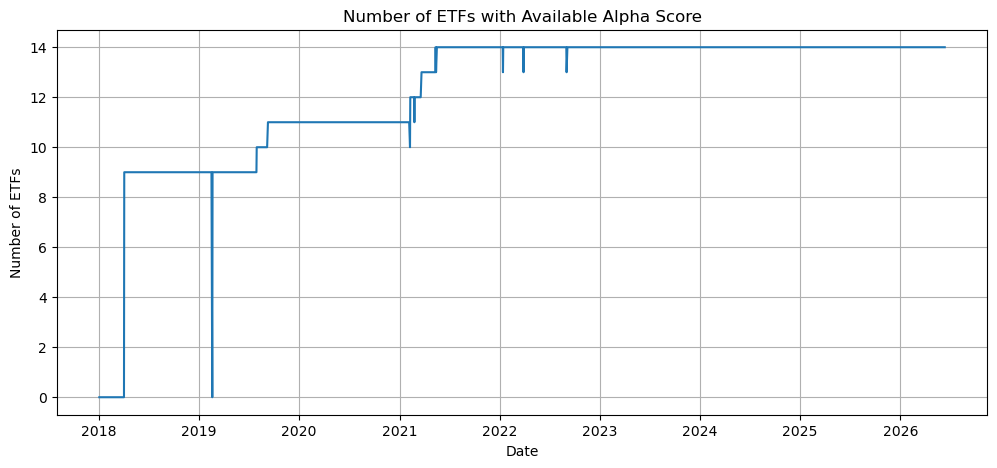

In [25]:
asset_count_by_date = (
    factor_data
    .groupby("date")["alpha_score"]
    .apply(lambda x: x.notna().sum())
)

plt.figure(figsize=(12, 5))
plt.plot(asset_count_by_date.index, asset_count_by_date.values)
plt.title("Number of ETFs with Available Alpha Score")
plt.xlabel("Date")
plt.ylabel("Number of ETFs")
plt.grid(True)
plt.show()

# Cell 21: 画Alpha得分分布

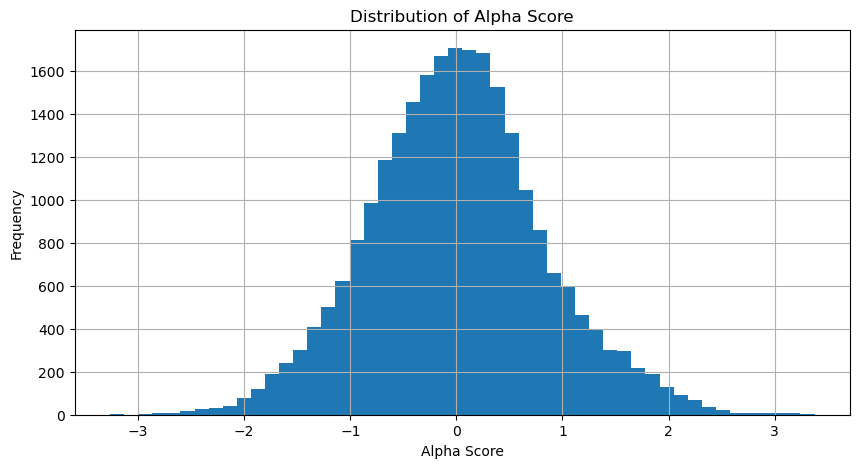

In [26]:
plt.figure(figsize=(10, 5))
plt.hist(factor_data["alpha_score"].dropna(), bins=50)
plt.title("Distribution of Alpha Score")
plt.xlabel("Alpha Score")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# Cell 22：检查每日Top 1 ETF

In [27]:
top1_by_date = (
    factor_data
    .dropna(subset=["alpha_score"])
    .sort_values(["date", "alpha_rank"])
    .groupby("date")
    .head(1)
    [["date", "symbol", "name", "alpha_score", "future_return_1d", "future_return_5d"]]
    .reset_index(drop=True)
)

top1_by_date.head(20)

,date,symbol,name,alpha_score,future_return_1d,future_return_5d
0,2018-04-03,159915,创业板ETF,1.263204,-0.018141,-0.024943
1,2018-04-04,512660,军工ETF,1.464636,0.028037,-0.001168
2,2018-04-09,512660,军工ETF,1.630717,-0.027273,-0.020455
3,2018-04-10,518880,黄金ETF,1.384922,0.005904,0.007011
4,2018-04-11,518880,黄金ETF,1.651827,0.003302,0.000367
5,2018-04-12,518880,黄金ETF,1.701373,-0.007678,-0.000366
6,2018-04-13,512660,军工ETF,1.424586,0.008187,0.035088
7,2018-04-16,518880,黄金ETF,1.390238,0.001468,-0.006239
8,2018-04-17,518880,黄金ETF,1.459544,-0.000733,-0.010627
9,2018-04-18,512660,军工ETF,1.346206,0.025287,0.000000


# Cell 23:统计 Top1 ETF出现频率

In [28]:
top1_frequency = (
    top1_by_date
    .groupby(["symbol", "name"])
    .size()
    .reset_index(name="top1_count")
    .sort_values("top1_count", ascending=False)
)

top1_frequency

,symbol,name,top1_count
12,518880,黄金ETF,489
8,513100,纳指ETF,297
6,512690,酒ETF,268
9,513500,标普500ETF,225
5,512660,军工ETF,101
4,512170,医疗ETF,100
7,512880,证券ETF,97
11,516160,新能源ETF,82
10,515790,光伏ETF,80
0,159915,创业板ETF,75


# Cell 24：保存 Top1 频率报告

In [30]:
top1_frequency_file = PROCESSED_DIR / "top1_frequency_report.csv"

top1_frequency.to_csv(top1_frequency_file, index=False, encoding="utf-8-sig")

print(f"已保存 Top 1 频率报告: {top1_frequency_file}")

已保存 Top 1 频率报告: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\top1_frequency_report.csv


# Cell 25：最终检查

In [31]:
print("第二部分完成。")
print("=" * 50)
print("输出文件：")
print(factor_output_file)
print(alpha_output_file)
print(quality_output_file)
print(top1_frequency_file)
print("=" * 50)

print("因子数据形状:", factor_data.shape)
print("日期范围:", factor_data["date"].min(), "到", factor_data["date"].max())
print("ETF 数量:", factor_data["symbol"].nunique())
print("Alpha 非缺失样本数:", factor_data["alpha_score"].notna().sum())

第二部分完成。
输出文件：
C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\etf_factors_long.csv
C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\etf_alpha_score_long.csv
C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\factor_quality_report.csv
C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\top1_frequency_report.csv
因子数据形状: (25810, 32)
日期范围: 2018-01-02 00:00:00 到 2026-06-12 00:00:00
ETF 数量: 14
Alpha 非缺失样本数: 24961
